In [1]:
import sys
sys.path.append("/project01/ndcms/atownse2/ExponentialMixtureModel")

import ROOT
import numpy as np
import matplotlib.pyplot as plt

from tools import scale_out as so
import emm

Welcome to JupyROOT 6.30/04


In [2]:
# Load the data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)

data_tree = emm.get_data(tree=True)
data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))

Loaded 5036 diphoton invariant masses from data.


In [3]:
# Get the binning for the visualization
bins = emm.get_fine_binning()

In [4]:
fit_options = [
    # ROOT.RooFit.IntegrateBins(0.0001),
    ROOT.RooFit.PrintLevel(-1),
    # ROOT.RooFit.Offset(True),
    # ROOT.RooFit.Strategy(2),
    ROOT.RooFit.Save(),
    # ROOT.RooFit.Range("fit_range")
]

In [5]:
# Do model selection
model_primitives = [
    emm.ExponentialMixtureModel_1,
    emm.ExponentialMixtureModel_2,
    emm.ExponentialMixtureModel_3,
    emm.ExponentialMixtureModel_4,
]

results = {}

for mp in model_primitives:
    print(f"Fitting {mp.name}...")
    fit_result = emm.fit_random_restarts(
        x, data, mp,
        seed=42,
        n_samples=20, n_retries=5,
        save=False, fit_options=fit_options
    )
    print(f"   Number of minima found: {len(fit_result)}")
    print(f"   NLLs: {[res['nll'] for res in fit_result]}")

    best_fit = fit_result[-1]
    model = mp(x)
    model.set_params(best_fit["final_pars"])

    aic = 2*len(model.params()) + 2*best_fit["nll"]
    bic = len(model.params())*np.log(data.numEntries()) + 2*best_fit["nll"]
    print(f"   Best fit: nll = {best_fit['nll']:.1f}")
    print(f"   AIC: {aic:.1f}, BIC: {bic:.1f}")
    results[model.n_components] = {
        "AIC": aic,
        "BIC": bic,
        "nll": best_fit["nll"],
    }


Fitting ExponentialMixture-1...
   Number of minima found: 3
   NLLs: [31096.40617617269, 31096.40617617233, 31096.4061761716]
   Best fit: nll = 31096.4
   AIC: 62196.8, BIC: 62209.9
Fitting ExponentialMixture-2...
   Number of minima found: 3
   NLLs: [31030.831915345258, 31030.83191088624, 31030.83190930537]
   Best fit: nll = 31030.8
   AIC: 62069.7, BIC: 62095.8
Fitting ExponentialMixture-3...
   Number of minima found: 5
   NLLs: [31030.832297936413, 31030.83211617754, 31030.83211087666, 31030.831979748564, 31030.831934008853]
   Best fit: nll = 31030.8
   AIC: 62073.7, BIC: 62112.8
Fitting ExponentialMixture-4...
   Number of minima found: 2
   NLLs: [31030.832213824153, 31030.831913201386]
   Best fit: nll = 31030.8
   AIC: 62077.7, BIC: 62129.9
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (pdf_0)
[#1] INFO:Minimization -- RooAbsMinimi

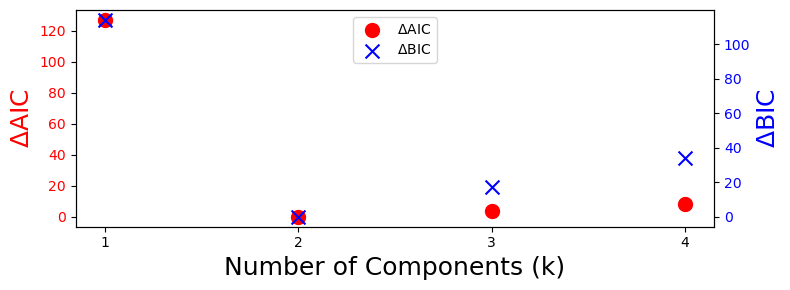

(<Figure size 800x300 with 2 Axes>,
 <Axes: xlabel='Number of Components (k)', ylabel='$\\Delta\\text{AIC}$'>,
 <Axes: ylabel='$\\Delta\\text{BIC}$'>)

In [6]:
criteria_by_k = {}
n_observations = data.numEntries()
for k, result in results.items():

    criteria_by_k[k] = emm.compute_information_criteria(
        result["nll"],
        2 * k - 1,
        n_observations,
    )

emm.plot_information_criteria(criteria_by_k)

In [17]:
# Fit and plot
model_primitives = [
    # emm.f1,
    # emm.f2,
    # emm.f3,
    # emm.f4,
    emm.ExponentialMixtureModel_2,
    # emm.GeneralizedPareto,
]

# For visualization
from array import array
bin_array = array('d', bins)
binning = ROOT.RooBinning(len(bins) - 1, bin_array)
x.setBinning(binning)

# For chi2
hist_name = f"diphoton_binned_data_hist_{ROOT.TUUID().AsString().replace('-', '_')}"
hist = ROOT.TH1D(hist_name, "Binned Data", len(bins) - 1, bin_array)
hist.SetDirectory(0)
data.fillHistogram(hist, ROOT.RooArgList(x))

binned_data_name = f"binned_data_{ROOT.TUUID().AsString().replace('-', '_')}"
binned_data = ROOT.RooDataHist(
    binned_data_name,
    "Binned Data",
    ROOT.RooArgList(x),
    hist,
    )

models = []
model_labels = []
model_results = []
for model_primitive in model_primitives:
    print(f"Fitting model: {model_primitive.name}")
    t0 = ROOT.TStopwatch()
    fit_result = emm.fit_random_restarts(
        x, data, model_primitive,
        seed=42, n_samples=20, n_retries=5,
        save=False,
        fit_options=fit_options
        )
    t1 = t0.RealTime()
    print(f"   Fit time: {t1:.1f} seconds")
    print(f"   Number of minima found: {len(fit_result)}")
    print(f"   NLLs: {[res['nll'] for res in fit_result]}")
    best_fit = fit_result[-1]
    model = model_primitive(x)
    model.set_params(best_fit["final_pars"])
    if "ExponentialMixture" in model.name:
        k = model.name.split("-")[-1]
        model_label = f"Exponential Mixture"
    else:
        model_func = "_".split(model.name)[0]
        model_num = model.name.split("_")[-1]
        model_label = f"#it{{f}}_{{{model_num}}}"

    nll = best_fit["nll"]
    n = data.numEntries()
    k = len(model.params())
    aic = 2*k + 2*nll
    bic = k*np.log(n) + 2*nll
    print(f"   AIC: {aic:.1f}, BIC: {bic:.1f}")

    chi2_res = emm.chi2(
        x,
        hist,
        model,
        min_events=30,
        print_chi2=True,
        )
    
    models.append(model)
    model_labels.append(model_label)
    model_results.append({
        "model": model,
        "label": model_label,
        "nll": nll,
        "aic": aic,
        "bic": bic,
        "chi2": chi2_res["chi2"],
        "chi2_ndf": chi2_res["chi2_ndf"],
    })

Fitting model: ExponentialMixture-2
   Fit time: 1.3 seconds
   Number of minima found: 4
   NLLs: [31030.826429147255, 31030.826426152904, 31030.826425677045, 31030.82642474516]
   AIC: 62069.7, BIC: 62095.8
chi2=50.58, ndf=56, chi2/ndf=0.903, 
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (pdf_0,pdf_1)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (pdf_0,pdf_1)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be

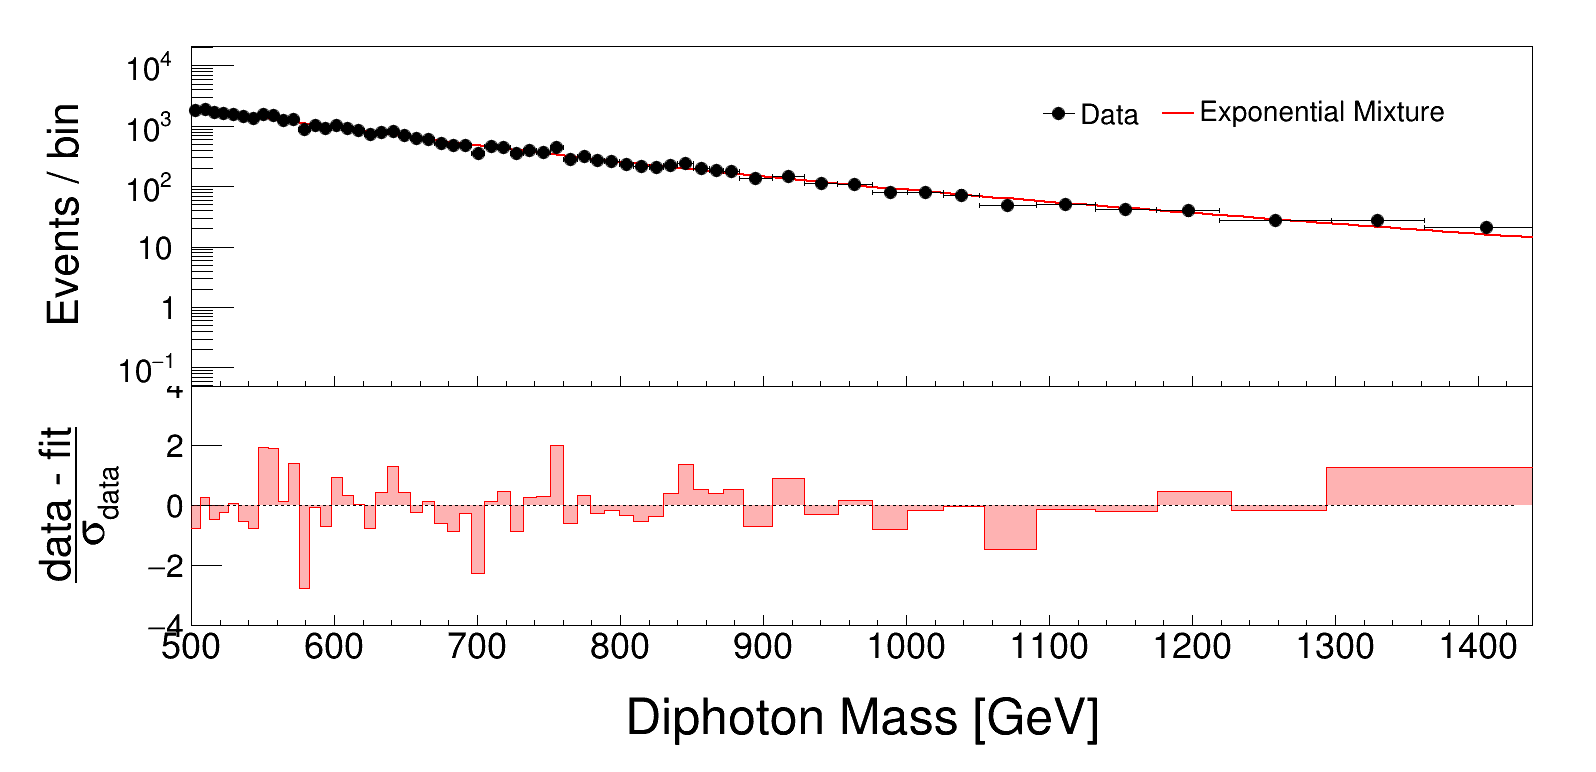

In [20]:
from array import array
import importlib
importlib.reload(emm)


emm.plot_fits(
    data, x, models,
    labels=model_labels,
    # title="CMS High Mass Diphoton Spectrum",
    colors=[ROOT.kRed],
    plot_range=(500, 1425),
    # nbins=128,
    y_min=5e-2,
    # logx=True,
    legend_bounds=(0.65, 0.56, 0.95, 0.85),
    legend_text_size=0.08,
    legend_columns=2,
    pull_fill_alpha=0.3
    )

In [15]:
# Format results into a latex table
print("\n\nLaTeX Table:")
print("\\begin{tabular}{lcccc}")
print("Model & $\\chi^2$ & $\\chi^2_\\nu$ & $\Delta$AIC & $\Delta$BIC \\\\")
aic_min = min(res["aic"] for res in model_results)
bic_min = min(res["bic"] for res in model_results)
print("\\hline")
for res in model_results:
    delta_aic = res["aic"] - aic_min
    delta_bic = res["bic"] - bic_min
    label = res['label'].replace('#it{', '').replace('}', '').replace('{', '')
    if "Exponential Mixture" in label:
        label = "Exponential Mixture"
    else:
        label = f"${label}$"
    print(f"{label} & {res['chi2']:.1f} & {res['chi2_ndf']:.2f} & {delta_aic:.1f} & {delta_bic:.1f} \\\\")
print("\\end{tabular}")



LaTeX Table:
\begin{tabular}{lcccc}
Model & $\chi^2$ & $\chi^2_\nu$ & $\Delta$AIC & $\Delta$BIC \\
\hline
$f_1$ & 54.2 & 0.93 & 1.6 & 1.6 \\
$f_2$ & 53.5 & 0.92 & 0.0 & 0.0 \\
$f_3$ & 54.7 & 0.94 & 2.5 & 2.5 \\
$f_4$ & 53.4 & 0.94 & 1.9 & 8.4 \\
Exponential Mixture & 50.6 & 0.90 & 1.2 & 14.2 \\
\end{tabular}


In [35]:
hist_name = f"diphoton_binned_data_hist_{ROOT.TUUID().AsString().replace('-', '_')}"
hist = ROOT.TH1D(hist_name, "Binned Data", len(bins) - 1, bin_array)
hist.SetDirectory(0)
data.fillHistogram(hist, ROOT.RooArgList(x))

binned_data_name = f"binned_data_{ROOT.TUUID().AsString().replace('-', '_')}"
binned_data = ROOT.RooDataHist(
    binned_data_name,
    "Binned Data",
    ROOT.RooArgList(x),
    hist,
    )
print(f"Number of bins in binned data: {binned_data.numEntries()}")

for model in models:
    print(f"Evaluating model: {model.name}")
    emm.chi2(
        x,
        hist,
        model,
        min_events=30,
        print_chi2=True,
        )

Number of bins in binned data: 169
Evaluating model: f_1
chi2=54.26, ndf=58, chi2/ndf=0.935, 
Evaluating model: f_2
chi2=53.49, ndf=58, chi2/ndf=0.922, 
Evaluating model: f_3
chi2=54.83, ndf=58, chi2/ndf=0.945, 
Evaluating model: f_4
chi2=53.41, ndf=57, chi2/ndf=0.937, 
Evaluating model: ExponentialMixture-2
chi2=50.58, ndf=56, chi2/ndf=0.903, 
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_4_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
